In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme()

# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

# df = df.drop(columns=['arr', 'm1', 'tidan', 'bam'], axis=1)
# df = df[['bam', 'four_world', 'quantstream', 'm1', 'vadantia', 'sp500', 'arr']]
# 2. Compute the correlation matrix
# 'min_periods' ensures we have at least N overlapping data points 
# to trust the correlation score. Adjust this based on your dataset size.
# corr_matrix = df.corr(method='pearson', min_periods=3)

df.head()

,maple_cap,arr,quantstream,tidan,four_world,wizard_quant,global_sigma,m1,sp500,vadantia,enko,bam,cambrian,brummer
date,,,,,,,,,,,,,,
2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.018929,NaN,NaN,NaN,NaN,NaN
2000-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.097829,NaN,NaN,NaN,NaN,NaN
2000-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.030086,NaN,NaN,NaN,NaN,NaN
2000-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020518,NaN,NaN,NaN,NaN,NaN
2000-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024654,NaN,NaN,NaN,NaN,NaN


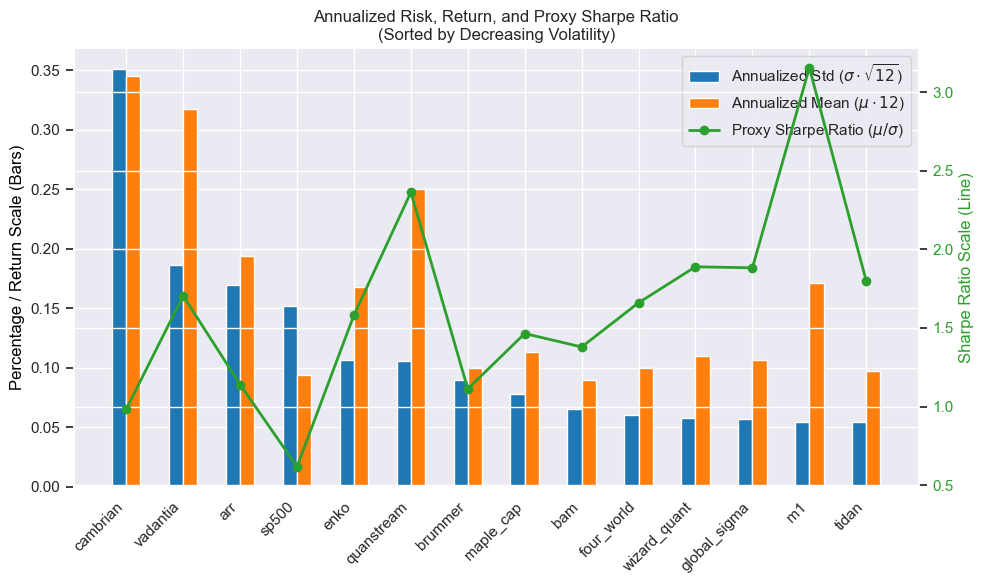

In [19]:
# 2. Compute annualized metrics
stats_df = pd.DataFrame(
    {
        "Annualized Mean": df.mean() * 12,
        "Annualized Std": df.std() * np.sqrt(12),
    }
)

# Calculate the Proxy Sharpe Ratio
stats_df["Proxy Sharpe"] = stats_df["Annualized Mean"] / stats_df["Annualized Std"]

# 3. Sort by decreasing standard deviation
stats_df = stats_df.sort_values(by="Annualized Std", ascending=False)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(stats_df.index))  # Label locations
width = 0.25  # Slightly narrower bars to accommodate the layout cleanly

# Plot the Mean and Std bars on the primary left y-axis (ax1)
rects1 = ax1.bar(
    x - width / 2,
    stats_df["Annualized Std"],
    width,
    label="Annualized Std ($\sigma \cdot \sqrt{12}$)",
    color="#1f77b4",
)
rects2 = ax1.bar(
    x + width / 2,
    stats_df["Annualized Mean"],
    width,
    label="Annualized Mean ($\mu \cdot 12$)",
    color="#ff7f0e",
)

# Labeling the primary axis
ax1.set_ylabel("Percentage / Return Scale (Bars)", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df.index, rotation=45, ha="right")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Create the secondary y-axis on the right (ax2) for the ratio
ax2 = ax1.twinx()
(line,) = ax2.plot(
    x,
    stats_df["Proxy Sharpe"],
    color="#2ca02c",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Proxy Sharpe Ratio ($\mu / \sigma$)",
)

# Labeling the secondary axis
ax2.set_ylabel("Sharpe Ratio Scale (Line)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

# Combine legends from both axes into a single legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title(
    "Annualized Risk, Return, and Proxy Sharpe Ratio\n(Sorted by Decreasing Volatility)"
)
plt.tight_layout()
plt.show()

In [20]:
stats_df = stats_df.drop(['sp500', 'bam', 'maple_cap', 'tidan'])

stats_df

,Annualized Mean,Annualized Std,Proxy Sharpe
cambrian,0.345333,0.351293,0.983035
vadantia,0.317571,0.186295,1.704671
arr,0.193500,0.169736,1.140005
enko,0.167906,0.106149,1.581798
quantstream,0.249832,0.105700,2.363604
brummer,0.099696,0.089649,1.112070
four_world,0.099630,0.060003,1.660427
wizard_quant,0.109597,0.057997,1.889715
global_sigma,0.106487,0.056549,1.883099
m1,0.171240,0.054253,3.156331


In [22]:
percentage_weights = (1 / stats_df['Annualized Std']) / (1 / stats_df['Annualized Std']).sum()

percentage_weights * 7_000_000

cambrian        1.745379e+05
vadantia        3.291231e+05
arr             3.612311e+05
enko            5.776223e+05
quantstream      5.800772e+05
brummer         6.839365e+05
four_world      1.021850e+06
wizard_quant    1.057201e+06
global_sigma    1.084270e+06
m1              1.130151e+06
Name: Annualized Std, dtype: float64